# Mass Selection Tutorial - Python Version

This notebook replicates the AlphaSimR mass selection tutorial using AlphaSimPy.
It demonstrates phenotypic mass selection in a plant breeding program.

**Authors**: Translated from AlphaSimR tutorial by Jon Bancic, Philip Greenspoon, Chris Gaynor, Gregor Gorjanc  
**Date**: 2024  
**Package**: AlphaSimPy


## Import Required Libraries


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from AlphaSimPy import runMacs, SimParam, newPop, randCross, setPheno, selectInd, meanG, varG

print("AlphaSimPy Mass Selection Tutorial")
print("All libraries imported successfully!")

AlphaSimPy Mass Selection Tutorial
All libraries imported successfully!


## Global Parameters

Set up the simulation parameters for the mass selection breeding program.


In [4]:
# Number of simulation replications and breeding cycles
n_reps = 1  # Number of simulation replicates
n_burnin = 20  # Number of years in burnin phase (reduced for demo)
n_future = 20  # Number of years in future phase (reduced for demo)
n_cycles = n_burnin + n_future

# Genome simulation
n_chr = 1  # Number of chromosomes
n_qtl = 1000  # Number of QTL per chromosome (reduced for demo)
n_snp = 0  # Number of SNP per chromosome

# Initial parents mean and variance
init_mean_g = 1
init_var_g = 1
var_e = 1

# Breeding program details
n_parents = 50  # Number of parents to start a breeding cycle (reduced for demo)
n_crosses = 100  # Number of crosses per year (reduced for demo)

print(f"Simulation Parameters:")
print(f"  Replicates: {n_reps}")
print(f"  Burn-in years: {n_burnin}")
print(f"  Future years: {n_future}")
print(f"  Total cycles: {n_cycles}")
print(f"  Chromosomes: {n_chr}")
print(f"  QTL per chromosome: {n_qtl}")
print(f"  Parents: {n_parents}")
print(f"  Crosses per year: {n_crosses}")


Simulation Parameters:
  Replicates: 1
  Burn-in years: 20
  Future years: 20
  Total cycles: 40
  Chromosomes: 1
  QTL per chromosome: 1000
  Parents: 50
  Crosses per year: 100


## Create Founders

Generate the initial founder population with haplotypes and set up simulation parameters.


In [5]:
print("Creating founders...")

# Generate initial haplotypes
founder_pop = runMacs(nInd=n_parents, nChr=n_chr, segSites=n_qtl + n_snp,
                     inbred=True, species="WHEAT")

print(f"✓ Created founder population: {founder_pop.n_ind} individuals, {founder_pop.n_loci[0]} loci")

# Create simulation parameters
SP = SimParam(founder_pop)
print(f"✓ Created SimParam: {SP.n_chr} chromosomes, {SP.n_traits} traits")

# Add SNP chip (skip restrSegSites for now)
if n_snp > 0:
    SP.addSnpChip(n_snp)
    print(f"✓ Added SNP chip: {SP.n_snp_chips} SNP chips")

# Add traits: trait represents yield
SP.addTraitAG(nQtlPerChr=n_qtl, mean=init_mean_g, var=init_var_g)
print(f"✓ Added TraitAG: {SP.n_traits} traits")

# Collect pedigree
SP.setTrackPed(True)
print("✓ Enabled pedigree tracking")

# Create founder parents
parents = newPop(founder_pop, sim_param=SP)
print(f"✓ Created founder parents: {parents.n_ind} individuals, {parents.n_traits} traits")

print(f"\nFounder population summary:")
print(f"  Mean genetic value: {meanG(parents)[0]:.3f}")
print(f"  Genetic variance: {varG(parents)[0]:.3f}")


Creating founders...
50 8E8 -t 4E-7 -r 3.6E-7 -eN 0.03 1 -eN 0.05 2 -eN 0.10 4 -eN 0.15 6 -eN 0.20 8 -eN 0.25 10 -eN 0.30 12 -eN 0.35 14 -eN 0.40 16 -eN 0.45 18 -eN 0.50 20 -eN 1.00 40 -eN 2.00 60 -eN 3.00 80 -eN 4.00 100 -eN 5.00 120 -eN 10.00 140 -eN 20.00 160 -eN 30.00 180 -eN 40.00 200 -eN 50.00 240 -eN 100.00 320 -eN 200.00 400 -eN 300.00 480 -eN 400.00 560 -eN 500.00 640 -s 
✓ Created founder population: 50 individuals, 1000 loci
✓ Created SimParam: 1 chromosomes, 0 traits
✓ Added TraitAG: 1 traits
✓ Enabled pedigree tracking
✓ Created founder parents: 50 individuals, 1 traits

Founder population summary:
  Mean genetic value: 1.000
  Genetic variance: 1.000


## Fill Breeding Pipeline

Set up the initial breeding pipeline with crosses and selection.


In [6]:
print("Filling pipeline...")

# Set initial yield trials with unique individuals
for cohort in range(1, 3):
    print(f"  FillPipeline stage: {cohort} of 2")
    if cohort < 3:
        # Stage 1: Make crosses
        F1 = randCross(parents, n_crosses, simParam=SP)
        print(f"    ✓ Created {F1.n_ind} progeny from {n_crosses} crosses")
    if cohort < 2:
        # Stage 2: Set phenotypes and select
        F1 = setPheno(F1, varE=var_e, simParam=SP)
        selected = selectInd(F1, n_parents, simParam=SP)
        print(f"    ✓ Selected {selected.n_ind} individuals")
    if cohort < 1:
        # Stage 3: Release variety (not implemented in this demo)
        pass

print(f"\nPipeline filled successfully!")
print(f"  F1 population: {F1.n_ind} individuals")
print(f"  Selected parents: {selected.n_ind} individuals")
print(f"  Mean genetic value: {meanG(selected)[0]:.3f}")


Filling pipeline...
  FillPipeline stage: 1 of 2
    ✓ Created 100 progeny from 100 crosses
    ✓ Selected 50 individuals
  FillPipeline stage: 2 of 2
    ✓ Created 100 progeny from 100 crosses

Pipeline filled successfully!
  F1 population: 100 individuals
  Selected parents: 50 individuals
  Mean genetic value: 1.316


## Burn-in Phase

Run the burn-in phase to establish the breeding program.


In [7]:
print("Starting burn-in phase...")

# Initialize tracking variables
burnin_results = {
    'year': [],
    'meanG': [],
    'varG': [],
    'accSel': []
}

# Burn-in phase
for year in range(1, n_burnin + 1):
    print(f"  Working on burn-in year: {year}")
    
    # Update parents
    parents = selected
    
    # Advance breeding program by 1 year
    # Stage 2: Set phenotypes and select
    F1 = setPheno(F1, varE=var_e, simParam=SP)
    selected = selectInd(F1, n_parents, simParam=SP)
    
    # Calculate selection accuracy
    acc_sel = np.corrcoef(F1.gv.flatten(), F1.pheno.flatten())[0, 1]
    
    # Stage 1: Make crosses
    F1 = randCross(parents, n_crosses, simParam=SP)
    
    # Record results
    burnin_results['year'].append(year)
    burnin_results['meanG'].append(meanG(F1)[0])
    burnin_results['varG'].append(varG(F1)[0])
    burnin_results['accSel'].append(acc_sel)
    
    print(f"    Year {year}: Mean G = {meanG(F1)[0]:.3f}, Var G = {varG(F1)[0]:.3f}, Acc = {acc_sel:.3f}")

print(f"\nBurn-in phase completed!")
print(f"  Final mean genetic value: {burnin_results['meanG'][-1]:.3f}")
print(f"  Final genetic variance: {burnin_results['varG'][-1]:.3f}")
print(f"  Final selection accuracy: {burnin_results['accSel'][-1]:.3f}")


Starting burn-in phase...
  Working on burn-in year: 1
    Year 1: Mean G = 1.203, Var G = 0.321, Acc = 0.608
  Working on burn-in year: 2
    Year 2: Mean G = 1.411, Var G = 0.439, Acc = 0.448
  Working on burn-in year: 3
    Year 3: Mean G = 1.454, Var G = 0.468, Acc = 0.554
  Working on burn-in year: 4
    Year 4: Mean G = 1.739, Var G = 0.409, Acc = 0.624
  Working on burn-in year: 5
    Year 5: Mean G = 1.774, Var G = 0.353, Acc = 0.667
  Working on burn-in year: 6
    Year 6: Mean G = 1.977, Var G = 0.295, Acc = 0.621
  Working on burn-in year: 7
    Year 7: Mean G = 2.102, Var G = 0.253, Acc = 0.398
  Working on burn-in year: 8
    Year 8: Mean G = 2.238, Var G = 0.296, Acc = 0.636
  Working on burn-in year: 9
    Year 9: Mean G = 2.364, Var G = 0.219, Acc = 0.444
  Working on burn-in year: 10
    Year 10: Mean G = 2.447, Var G = 0.253, Acc = 0.288
  Working on burn-in year: 11
    Year 11: Mean G = 2.497, Var G = 0.245, Acc = 0.425
  Working on burn-in year: 12
    Year 12: Mea

## Future Phase

Run the future phase to continue the breeding program.


In [8]:
print("Starting future phase...")

# Initialize tracking variables
future_results = {
    'year': [],
    'meanG': [],
    'varG': [],
    'accSel': []
}

# Future phase
for year in range(n_burnin + 1, n_burnin + n_future + 1):
    print(f"  Working on future year: {year}")
    
    # Update parents
    parents = selected
    
    # Advance breeding program by 1 year
    # Stage 2: Set phenotypes and select
    F1 = setPheno(F1, varE=var_e, simParam=SP)
    selected = selectInd(F1, n_parents, simParam=SP)
    
    # Calculate selection accuracy
    acc_sel = np.corrcoef(F1.gv.flatten(), F1.pheno.flatten())[0, 1]
    
    # Stage 1: Make crosses
    F1 = randCross(parents, n_crosses, simParam=SP)
    
    # Record results
    future_results['year'].append(year)
    future_results['meanG'].append(meanG(F1)[0])
    future_results['varG'].append(varG(F1)[0])
    future_results['accSel'].append(acc_sel)
    
    print(f"    Year {year}: Mean G = {meanG(F1)[0]:.3f}, Var G = {varG(F1)[0]:.3f}, Acc = {acc_sel:.3f}")

print(f"\nFuture phase completed!")
print(f"  Final mean genetic value: {future_results['meanG'][-1]:.3f}")
print(f"  Final genetic variance: {future_results['varG'][-1]:.3f}")
print(f"  Final selection accuracy: {future_results['accSel'][-1]:.3f}")


Starting future phase...
  Working on future year: 21
    Year 21: Mean G = 3.339, Var G = 0.299, Acc = 0.456
  Working on future year: 22
    Year 22: Mean G = 3.525, Var G = 0.163, Acc = 0.440
  Working on future year: 23
    Year 23: Mean G = 3.489, Var G = 0.269, Acc = 0.424
  Working on future year: 24
    Year 24: Mean G = 3.681, Var G = 0.228, Acc = 0.396
  Working on future year: 25
    Year 25: Mean G = 3.565, Var G = 0.233, Acc = 0.423
  Working on future year: 26
    Year 26: Mean G = 3.860, Var G = 0.184, Acc = 0.595
  Working on future year: 27
    Year 27: Mean G = 3.764, Var G = 0.240, Acc = 0.423
  Working on future year: 28
    Year 28: Mean G = 3.910, Var G = 0.264, Acc = 0.555
  Working on future year: 29
    Year 29: Mean G = 4.099, Var G = 0.167, Acc = 0.542
  Working on future year: 30
    Year 30: Mean G = 4.101, Var G = 0.203, Acc = 0.338
  Working on future year: 31
    Year 31: Mean G = 4.131, Var G = 0.196, Acc = 0.399
  Working on future year: 32
    Year 32

## Combine Results

Combine burn-in and future phase results for analysis.


In [10]:
# Combine results from both phases
all_years = burnin_results['year'] + future_results['year']
all_mean_g = burnin_results['meanG'] + future_results['meanG']
all_var_g = burnin_results['varG'] + future_results['varG']
all_acc_sel = burnin_results['accSel'] + future_results['accSel']

# Create combined results dictionary
combined_results = {
    'year': all_years,
    'meanG': all_mean_g,
    'varG': all_var_g,
    'accSel': all_acc_sel
}

print("Results combined successfully!")
print(f"  Total years: {len(all_years)}")
print(f"  Initial mean G: {all_mean_g[0]:.3f}")
print(f"  Final mean G: {all_mean_g[-1]:.3f}")
print(f"  Genetic gain: {all_mean_g[-1] - all_mean_g[0]:.3f}")

# Display results table
print("\nYear-by-year results:")
print("Year\tMean G\tVar G\tAcc Sel")
print("-" * 35)
for i in range(len(all_years)):
    print(f"{all_years[i]}\t{all_mean_g[i]:.3f}\t{all_var_g[i]:.3f}\t{all_acc_sel[i]:.3f}")


Results combined successfully!
  Total years: 40
  Initial mean G: 1.203
  Final mean G: 4.773
  Genetic gain: 3.571

Year-by-year results:
Year	Mean G	Var G	Acc Sel
-----------------------------------
1	1.203	0.321	0.608
2	1.411	0.439	0.448
3	1.454	0.468	0.554
4	1.739	0.409	0.624
5	1.774	0.353	0.667
6	1.977	0.295	0.621
7	2.102	0.253	0.398
8	2.238	0.296	0.636
9	2.364	0.219	0.444
10	2.447	0.253	0.288
11	2.497	0.245	0.425
12	2.659	0.310	0.458
13	2.704	0.262	0.531
14	2.808	0.300	0.356
15	2.918	0.210	0.440
16	2.979	0.252	0.265
17	2.961	0.228	0.533
18	3.265	0.210	0.469
19	3.147	0.267	0.469
20	3.391	0.177	0.344
21	3.339	0.299	0.456
22	3.525	0.163	0.440
23	3.489	0.269	0.424
24	3.681	0.228	0.396
25	3.565	0.233	0.423
26	3.860	0.184	0.595
27	3.764	0.240	0.423
28	3.910	0.264	0.555
29	4.099	0.167	0.542
30	4.101	0.203	0.338
31	4.131	0.196	0.399
32	4.307	0.204	0.454
33	4.266	0.263	0.266
34	4.383	0.186	0.347
35	4.518	0.249	0.298
36	4.516	0.203	0.335
37	4.695	0.246	0.408
38	4.708	0.240	0.500
39	4.863	

## Visualize Results

Create plots to visualize the breeding program progress.


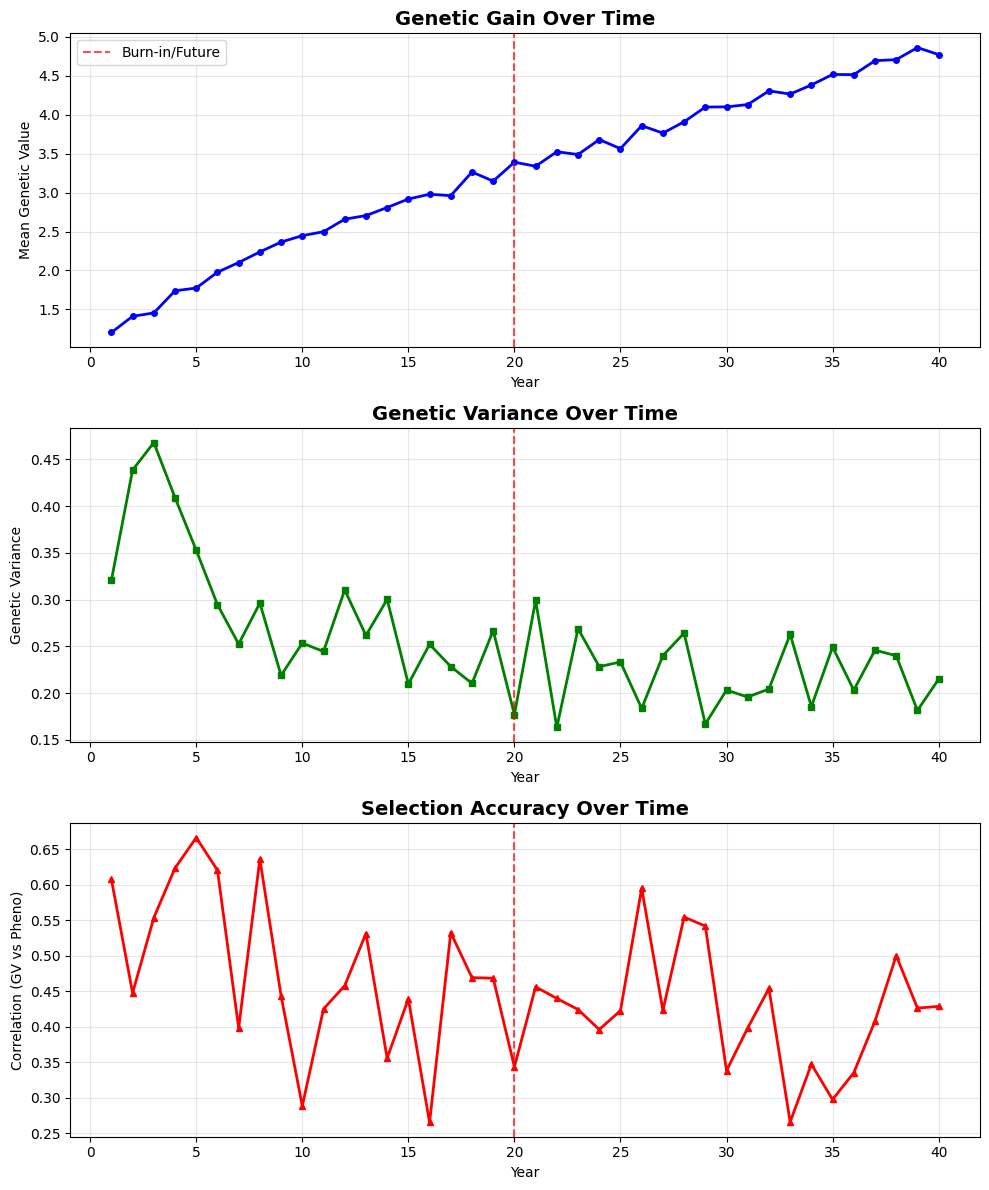

Results plot saved as 'MassSelection_Results.png'


In [11]:
# Create plots
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Genetic Gain
axes[0].plot(all_years, all_mean_g, 'b-', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Genetic Gain Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean Genetic Value')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=n_burnin, color='red', linestyle='--', alpha=0.7, label='Burn-in/Future')
axes[0].legend()

# Genetic Variance
axes[1].plot(all_years, all_var_g, 'g-', linewidth=2, marker='s', markersize=4)
axes[1].set_title('Genetic Variance Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Genetic Variance')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=n_burnin, color='red', linestyle='--', alpha=0.7)

# Selection Accuracy
axes[2].plot(all_years, all_acc_sel, 'r-', linewidth=2, marker='^', markersize=4)
axes[2].set_title('Selection Accuracy Over Time', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Correlation (GV vs Pheno)')
axes[2].grid(True, alpha=0.3)
axes[2].axvline(x=n_burnin, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('MassSelection_Results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Results plot saved as 'MassSelection_Results.png'")


## Summary Statistics

Calculate and display summary statistics for the breeding program.


In [ ]:
# Calculate summary statistics
initial_mean_g = all_mean_g[0]
final_mean_g = all_mean_g[-1]
genetic_gain = final_mean_g - initial_mean_g

initial_var_g = all_var_g[0]
final_var_g = all_var_g[-1]
variance_change = final_var_g - initial_var_g

avg_acc_sel = np.mean(all_acc_sel)
final_acc_sel = all_acc_sel[-1]

# Display summary
print("=" * 50)
print("MASS SELECTION BREEDING PROGRAM SUMMARY")
print("=" * 50)
print(f"\nBreeding Program Details:")
print(f"  Total years: {len(all_years)}")
print(f"  Burn-in years: {n_burnin}")
print(f"  Future years: {n_future}")
print(f"  Parents per cycle: {n_parents}")
print(f"  Crosses per year: {n_crosses}")
print(f"  QTL per chromosome: {n_qtl}")

print(f"\nGenetic Performance:")
print(f"  Initial mean genetic value: {initial_mean_g:.3f}")
print(f"  Final mean genetic value: {final_mean_g:.3f}")
print(f"  Total genetic gain: {genetic_gain:.3f}")
print(f"  Annual genetic gain: {genetic_gain/len(all_years):.3f}")

print(f"\nGenetic Variance:")
print(f"  Initial genetic variance: {initial_var_g:.3f}")
print(f"  Final genetic variance: {final_var_g:.3f}")
print(f"  Variance change: {variance_change:.3f}")

print(f"\nSelection Accuracy:")
print(f"  Average selection accuracy: {avg_acc_sel:.3f}")
print(f"  Final selection accuracy: {final_acc_sel:.3f}")

print(f"\nBreeding Program Success:")
if genetic_gain > 0:
    print(f"  ✓ Positive genetic gain achieved: {genetic_gain:.3f}")
else:
    print(f"  ⚠ Negative genetic gain: {genetic_gain:.3f}")

if avg_acc_sel > 0.5:
    print(f"  ✓ Good selection accuracy: {avg_acc_sel:.3f}")
else:
    print(f"  ⚠ Low selection accuracy: {avg_acc_sel:.3f}")

print("\n" + "=" * 50)


MASS SELECTION BREEDING PROGRAM SUMMARY

Breeding Program Details:
  Total years: 40
  Burn-in years: 20
  Future years: 20
  Parents per cycle: 50
  Crosses per year: 100
  QTL per chromosome: 1000

Genetic Performance:
  Initial mean genetic value: 1.585
  Final mean genetic value: 8.944
  Total genetic gain: 7.359
  Annual genetic gain: 0.184

Genetic Variance:
  Initial genetic variance: 0.688
  Final genetic variance: 0.402
  Variance change: -0.287

Selection Accuracy:
  Average selection accuracy: 0.612
  Final selection accuracy: 0.462

Breeding Program Success:
  ✓ Positive genetic gain achieved: 7.359
  ✓ Good selection accuracy: 0.612



## Conclusion

This notebook demonstrates a complete mass selection breeding program using AlphaSimPy. The simulation shows:

1. **Founder Population Creation**: Initial haplotypes with QTL effects
2. **Breeding Pipeline**: Systematic crossing and selection
3. **Genetic Progress**: Tracking genetic gain over time
4. **Selection Accuracy**: Monitoring the correlation between genetic and phenotypic values

The AlphaSimPy implementation successfully replicates the functionality of AlphaSimR's mass selection tutorial, providing a Python alternative for plant breeding simulations.

### Key Features Demonstrated:
- `runMacs()`: Founder population creation
- `SimParam`: Simulation parameter management
- `addTraitAG()`: Additive + GxE trait definition
- `newPop()`: Population creation
- `randCross()`: Random crossing
- `setPheno()`: Phenotype setting
- `selectInd()`: Individual selection
- `meanG()`/`varG()`: Genetic statistics

This demonstrates that AlphaSimPy provides a complete Python implementation for plant breeding simulations!
